In [9]:
%matplotlib notebook
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import optimize
from scipy import stats

Converged with chi-squared 18.11
Converged with P-Value 0.03
Number of degrees of freedom, dof = 9.00
Reduced chi-squared 2.01

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 9.938e-01                | 2.820e-02               
1           | 0.000e+00                | -8.616e-01               | 4.767e-02               
Converged with chi-squared 4.83
Converged with P-Value 0.68
Number of degrees of freedom, dof = 7.00
Reduced chi-squared 0.69

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 9.595e-01                | 4.445e-02               
1           | 0.000e+00                | -1.044e+00               | 4.047e-01               
2           | 0.000e+00                | 1.331e+00                | 9.694e-01               
3           | 0.000e+00                | -1.238e+00               | 

<IPython.core.display.Javascript object>


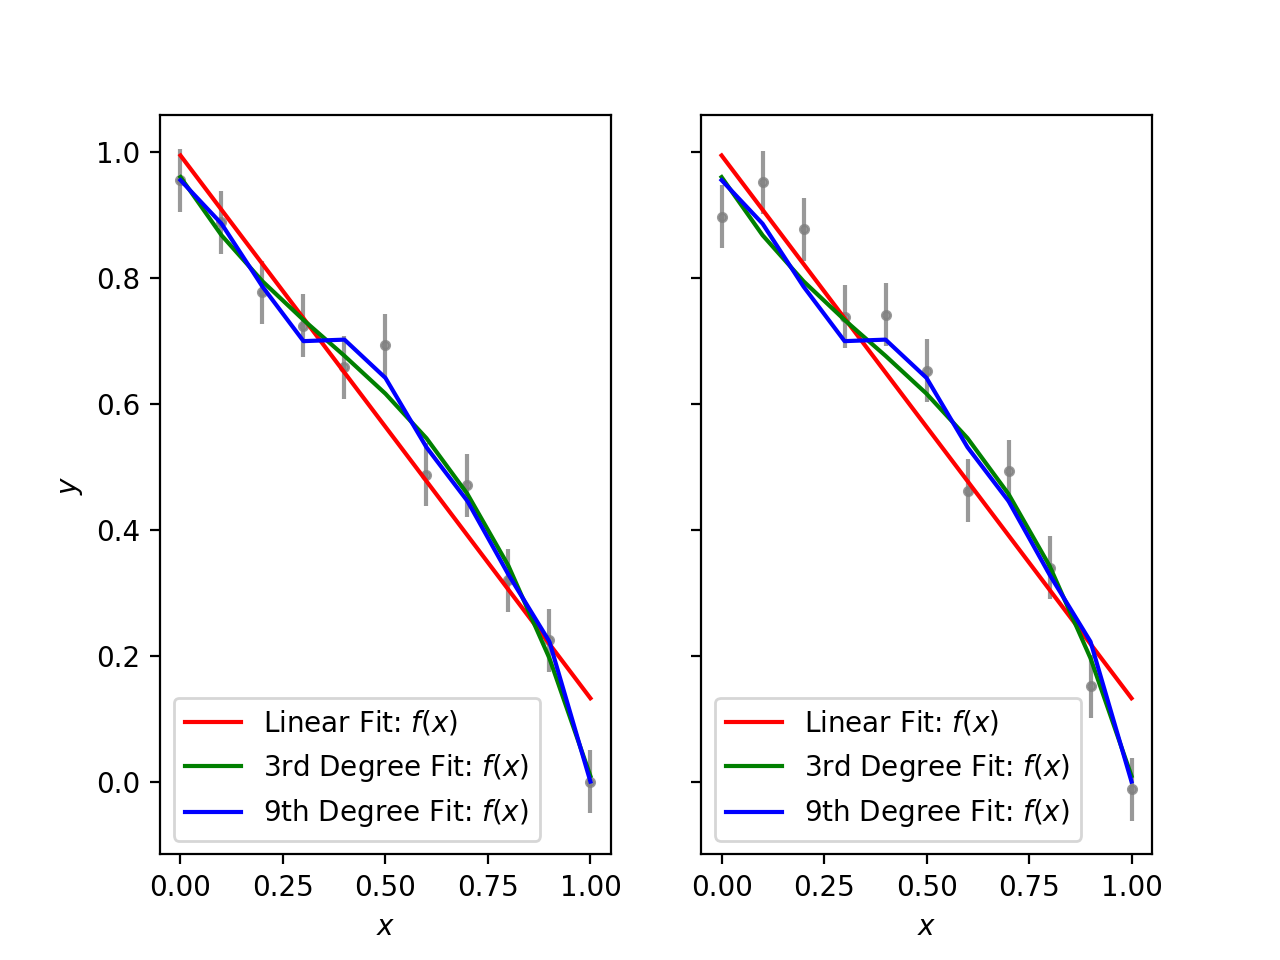

In [36]:
m = 11

x = np.linspace(0,1,m)

yt = 1 - x + x**2 - x**3
sy = 0.05
y1 = yt + sy*np.random.standard_normal(m)
y2 = yt + sy*np.random.standard_normal(m)

def linear(p, xvar):
    return p[0] + p[1]*xvar
def third(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2) + p[3]*(xvar **3)
def ninth(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2) + p[3]*(xvar **3) + p[4]*(xvar **4) + p[5]*(xvar **5) + p[6]*(xvar **6) + p[7]*(xvar **7)+ p[8]*(xvar **8) + p[9]*(xvar **9)
def residual(p,func, xvar, yvar, err):
    return (func(p, xvar) - yvar)/err
def data_fit(p0,func,xvar, yvar, err, tmi=0):
    try:
        fit = optimize.least_squares(residual, p0, args = (func, xvar, yvar, err),verbose=tmi)
    except Exception as error:
        print("Something has gone wrong:",error)
        return p0,np.zeros_like(p0),np.nan,np.nan
    pf = fit['x']

    try:
        cov = np.linalg.inv(fit['jac'].T.dot(fit['jac']))          
    except:
        return pf,np.zeros_like(pf),np.nan,np.nan
    chisq = sum(residual(pf,func,xvar, yvar, err) **2)
    dof = len(xvar) - len(pf)
    red_chisq = chisq/dof
    pferr = np.sqrt(np.diagonal(cov))
    # finds the uncertainty in fit parameters by squaring diagonal elements of the covariance matrix
    p_val = 1 - scipy.stats.chi2.cdf(chisq, dof)
    print('Converged with chi-squared {:.2f}'.format(chisq))
    print('Converged with P-Value {:.2f}'.format(p_val))
    print('Number of degrees of freedom, dof = {:.2f}'.format(dof))
    print('Reduced chi-squared {:.2f}'.format(red_chisq))
    print()
    Columns = ["Parameter #","Initial guess values:", "Best fit values:", "Uncertainties in the best fit values:"]
    print('{:<11}'.format(Columns[0]),'|','{:<24}'.format(Columns[1]),"|",'{:<24}'.format(Columns[2]),"|",'{:<24}'.format(Columns[3]))
    for num in range(len(pf)):
        print('{:<11}'.format(num),'|','{:<24.3e}'.format(p0[num]),'|','{:<24.3e}'.format(pf[num]),'|','{:<24.3e}'.format(pferr[num]))
    return pf, pferr, chisq, dof

pf1, perr1, chisq1, dof1 = data_fit([0,0],linear, x, y1, sy)
pf3, perr3, chisq3, dof3 = data_fit([0,0,0,0],third, x, y1, sy)
pf9, perr9, chisq9, dof9 = data_fit([0,0,0,0,0,0,0,0,0,0],ninth, x, y1, sy)

chisq12 = sum(residual(pf1,linear,x, y2, sy) **2)
dof12 = len(x) - len(pf1)
p_val12 = 1 - scipy.stats.chi2.cdf(chisq12, dof12)

chisq32 = sum(residual(pf3,third,x, y2, sy) **2)
dof32 = len(x) - len(pf3)
p_val32 = 1 - scipy.stats.chi2.cdf(chisq32, dof32)

chisq92 = sum(residual(pf9,ninth,x, y2, sy) **2)
dof92 = len(x) - len(pf9)
p_val92 = 1 - scipy.stats.chi2.cdf(chisq92, dof92)

print('Converged with P-Value Linear 2nd Data Set {:.2f}'.format(p_val12))
print('Converged with P-Value 3rd Degree 2nd Data Set {:.2f}'.format(p_val32))
print('Converged with P-Value 9th Degree 2nd Data Set {:.2f}'.format(p_val92))

fig, axx = plt.subplots(ncols=2,sharex=True,sharey=True)


axx[0].set_xlabel(r"$x$")
axx[0].set_ylabel(r"$y$")
axx[1].set_xlabel(r"$x$")

axx[0].plot(x, linear(pf1, x), 'r-', label = 'Linear Fit: $f(x)$')
axx[0].plot(x, third(pf3, x), 'g-', label = '3rd Degree Fit: $f(x)$')
axx[0].plot(x, ninth(pf9, x), 'b-', label = '9th Degree Fit: $f(x)$')

axx[1].plot(x, linear(pf1, x), 'r-', label = 'Linear Fit: $f(x)$')
axx[1].plot(x, third(pf3, x), 'g-', label = '3rd Degree Fit: $f(x)$')
axx[1].plot(x, ninth(pf9, x), 'b-', label = '9th Degree Fit: $f(x)$')

axx[0].errorbar(x,y1,sy,fmt=".",color="gray",alpha=0.8,zorder=-1)
axx[1].errorbar(x,y2,sy,fmt=".",color="gray",alpha=0.8,zorder=-1)

axx[0].legend()
axx[1].legend()